# Figures and Tables — Text-mined dataset of sol-gel synthesis protocols with phase purity outcomes

This notebook regenerates **every table and figure in the manuscript and the Supplementary
Information** from the released data files. Each item is labeled with its manuscript number.

Its scope is exactly the numbered figures and tables — nothing else. Statistics quoted only in
the running text (solvent-route purity fractions, temperature-window queries, leave-one-paper-out
robustness, end-to-end lower bounds, the semantic consistency counts) are not reproduced here;
the semantic consistency checks ship as `post-processing/semantic_inconsistency.py`, and
`tutorial.ipynb` covers the exploratory queries.

| Item | Source data | Notebook section |
|---|---|---|
| Figure 1 | — (schematic) | [Figure 1](#figure-1) |
| Table 1 | — (schema documentation) | [Table 1](#table-1) |
| Table 2, Figure 2, Figure 3a–c | `sol_gel_dataset.jsonl` | [Data Overview](#data-overview) |
| Tables 3–5, S2–S6, Figures S1–S4 | `validation/*.jsonl` | [Technical Validation](#technical-validation) |
| Figure 1, Table 1, Table S1, Supplementary Sec. 1–3 | — | [Not generated by code](#not-generated-by-code) |

### Running this notebook

```bash
unzip sol_gel_dataset.jsonl.zip          # from the repository root
pip install -r requirements.txt
jupyter notebook scripts/figures_tables.ipynb
```

The dataset itself is archived at <https://doi.org/10.6084/m9.figshare.33040070>.
Cells are written to be run **in order** — later cells reuse variables and helper
functions defined by earlier ones.

In [1]:
# =============================================================================
# Setup — paths and dataset load
#
# The notebook lives in scripts/ and reads from the repository root, so it works
# whether it is launched from scripts/ or from the repository root.
# =============================================================================

import json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
DATASET_FILE   = ROOT / "sol_gel_dataset.jsonl"
VALIDATION_DIR = ROOT / "validation"

records = []
with open(DATASET_FILE, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

unique_dois = len({r["protocol"]["doi"] for r in records})

print(f"Dataset file:  {DATASET_FILE}")
print(f"Total records: {len(records):,}")
print(f"Unique DOIs:   {unique_dois:,}")

Dataset file:  /Users/wesleychen/Documents/GitHub/sol-gel-data/sol_gel_dataset.jsonl
Total records: 148,024
Unique DOIs:   53,422


<a id="figure-1"></a>
## Figure 1 | Schematic representation of the data extraction pipeline

> *Gemini 3.0 Flash is used to filter for inorganic sol-gel papers and extract protocols,
> operations, and phase purity outcomes from text. Example text is adapted from Demidzu et al.*

**Not generated by code.** Figure 1 is a hand-drawn schematic; the rendered artwork is
committed at `scripts/images/sg-fig1.svg` (and `sg-fig1.png`). The example text it annotates
comes from <https://doi.org/10.1016/j.jmmm.2009.12.033>; the records extracted from that paper
are in `sol_gel_dataset.jsonl` under that DOI.

<a id="table-1"></a>
## Table 1 | Data records format

> *Each data record includes the synthesis protocol, synthesis operations, and phase purity
> information under the following top-level keys: `protocol`, `operations`, and `phase_purity`.*

**Not generated by code** — Table 1 documents the schema rather than reporting a measurement.
It is reproduced here so the notebook is self-contained.

| Data description | Data key label | Data type |
|---|---|---|
| **Synthesis protocol** | | |
| DOI of the original paper | `doi` | string |
| Target material of synthesis | `target` | dict: `material_string` (string), `material_formula` (string), `composition` (list of objects), `phase` (string), `material_form` (string), `is_mixture` (bool), `additives` (list of string), `oxygen_deficiency` (string), `oxidation_states` (dict) |
| Metal precursors used in synthesis | `metal_precursors` | list of objects — see `target` |
| Reagents used in synthesis (solvents, catalysts, additives, etc.) | `reagents` | list of dicts: `reagent_string` (string), `reagent_role` (string), `pubchem_CID` (int), `iupac_name` (string), `reagent_formula` (string), `smiles` (string) |
| **Synthesis operations** | | |
| Type of operation (mixing, heating, deposition, grinding, other) | `operation_type` | string |
| Time of operation | `time` | dict: `raw_string` (string), `max_value` (float), `min_value` (float), `unit` (string) |
| Temperature of operation | `temperature` | dict — see `time` |
| Any ratios between reagents or precursors of the operation | `ratios` | list of dict: `type` (string), `description` (string), `value` (string) |
| pH of operation | `pH` | dict: `raw_string` (string), `max_value` (float), `min_value` (float) |
| Atmospheric condition of operation (in air, N₂, etc.) | `atmosphere` | dict: `raw_string` (string), `atmosphere_normalized` (string) |
| Short description of operation step including any additional information not mentioned anywhere else | `operation_details` | string |
| **Phase purity information** | | |
| Impurity phase(s) | `impurity_phase` | list of objects — see `target` |
| Classification of phase purity based on text (i.e. impure, pure, insufficient info) | `classification` | string |
| Any additional details regarding phase purity outcome mentioned in text | `phase_purity_details` | string |
| Any characterization methods mentioned in text | `characterization_methods` | dict: `characterization_string` (list of string), `characterization_normalized` (list of string) |

<a id="data-overview"></a>
# Data Overview

<a id="table-2"></a>
## Table 2 | Most common ternary compounds with some of their top precursors, reagents, and impurity phases

> *Data records assigned with the "insufficient info" phase purity classification label are
> excluded from the analysis.*

`ternary_report(records)` prints the top-5 ternary compounds by record count with their
phase-pure fraction (pure / pure + impure), top precursors, top reagents, and most common
impurity phases. Pass `top_n=20` to extend the ranking, or `formula="BaTiO3"` to look up a
specific material. Precursor hydrate and nitrate variants are collapsed to a canonical form
(e.g. `Fe(NO3)3·9H2O` → `Fe(NO3)3`) so the counts match the manuscript table.

In [2]:
# TABLE 2 — most common ternary compounds

import re
from collections import Counter


def _is_ternary(entry):
    """Return True if the target has exactly 3 distinct elements.
    Reads from the stored composition field (set by text2chem during post-processing)."""
    target = entry.get("protocol", {}).get("target", {})
    symbols = {
        el
        for comp in (target.get("composition") or [])
        for el in (comp.get("elements") or {})
    }
    return len(symbols) == 3


def _normalize_precursor(formula):
    """Strip hydrate suffixes and normalize nitrate variants to a canonical form.
    e.g. Fe(NO3)3·9H2O -> Fe(NO3)3"""
    if not formula:
        return formula
    m = re.match(r'^(.+?\(NO3\)\d*)', formula)
    if m:
        return m.group(1)
    return re.sub(r'[·⋅•\*\.]?\s*\d*\s*H2O.*$', '', formula).strip() or formula


def ternary_report(dataset, top_n=5, formula=None):
    """
    Print a summary for the top ternary compounds by record count.

    Parameters
    ----------
    dataset : list
        The full list of records (e.g. `records`).
    top_n : int
        How many compounds to show (ranked by total record count). Default 5.
    formula : str or None
        If given, show only this specific formula instead of the top-N ranking.
        Example: formula="BaTiO3"
    """
    ternary = [d for d in dataset if _is_ternary(d)]

    if formula:
        subset_map = {formula: [d for d in ternary
                                 if d["protocol"]["target"].get("material_formula") == formula]}
    else:
        formula_counts = Counter(
            d["protocol"]["target"]["material_formula"] for d in ternary
        )
        subset_map = {
            f: [d for d in ternary if d["protocol"]["target"]["material_formula"] == f]
            for f, _ in formula_counts.most_common(top_n)
        }

    for f, subset in subset_map.items():
        if not subset:
            print(f"No ternary records found for {f!r}.")
            continue

        n_pure   = sum(1 for d in subset if d.get("phase_purity", {}).get("classification") == "Pure")
        n_impure = sum(1 for d in subset if d.get("phase_purity", {}).get("classification") == "Impure")
        denom    = n_pure + n_impure
        frac_str = f"{n_pure/denom:.1%}" if denom else "N/A"

        # Top precursors (hydrate/nitrate variants collapsed)
        prec_counter = Counter()
        for d in subset:
            for mp in d.get("protocol", {}).get("metal_precursors", []):
                f_prec = _normalize_precursor(mp.get("material_formula"))
                if f_prec:
                    prec_counter[f_prec] += 1

        # Top reagents (only those with a resolved PubChem CID)
        reag_counter = Counter()
        for d in subset:
            for r in d.get("protocol", {}).get("reagents", []):
                if r.get("pubchem_CID") and r.get("reagent_string"):
                    reag_counter[(r["pubchem_CID"], r["reagent_string"].strip())] += 1

        # Top impurity phases
        imp_counter = Counter()
        for d in subset:
            for phase in d.get("phase_purity", {}).get("impurity_phase", []):
                label = phase.get("material_formula") if isinstance(phase, dict) else phase
                if label:
                    imp_counter[label] += 1

        print(f"\n{'='*62}")
        print(f"  {f}  |  {len(subset):,} total records  |  Purity: {frac_str} ({n_pure}/{denom})")
        print(f"{'='*62}")

        print("  Top precursors:")
        for p, cnt in prec_counter.most_common(6):
            print(f"    {cnt:>4}  {p}")

        print("  Top reagents:")
        for (cid, name), cnt in reag_counter.most_common(6):
            print(f"    {cnt:>4}  {name} (CID: {cid})")

        print("  Top impurity phases:")
        if imp_counter:
            for p, cnt in imp_counter.most_common(6):
                print(f"    {cnt:>4}  {p}")
        else:
            print("    (none recorded)")


# Top 5 ternary compounds by total record count
ternary_report(records, top_n=5)

# Uncomment to query a specific compound:
# ternary_report(records, formula="SrTiO3")


  BiFeO3  |  1,220 total records  |  Purity: 66.1% (789/1194)
  Top precursors:
    1122  Fe(NO3)3
    1086  Bi(NO3)3
      35  Bi2O3
      22  Bi(NO3)2
      21  Bi(CH3COO)3
      17  Fe(CH3COCHCOCH3)3
  Top reagents:
     317  ethylene glycol (CID: 174)
     285  2-methoxyethanol (CID: 8019)
     270  nitric acid (CID: 944)
     267  citric acid (CID: 311)
     191  acetic acid (CID: 176)
     167  tartaric acid (CID: 444305)
  Top impurity phases:
     207  Bi2Fe4O9
      82  Bi25FeO40
      69  Bi2O3
      32  Fe2O3
      29  Bi25FeO39
      24  Bi24Fe2O39

  CoFe2O4  |  1,081 total records  |  Purity: 86.4% (911/1054)
  Top precursors:
     932  Fe(NO3)3
     819  Co(NO3)2
      88  Co(NO3)3
      35  Fe(NO3)2
      32  Co(CH3CO2)2
      30  FeCl3
  Top reagents:
     497  citric acid (CID: 311)
     241  distilled water (CID: 962)
     209  deionized water (CID: 962)
     136  water (CID: 962)
     133  ammonia (CID: 222)
     125  ethanol (CID: 702)
  Top impurity phases:
     

<a id="figure-2"></a>
## Figure 2 | Target materials elemental frequency and phase purity trends

> *Upper left triangle: total data records (10ˣ scale). Lower right triangle: average fraction
> of phase-pure records calculated from ternary compounds. Elements with less than three
> ternary compounds with at least ten data records each are excluded from phase purity
> analysis (dark gray). The figure includes 117,381 of the 148,024 records (79.3%). The
> remainder are excluded because the target formula could not be normalized by text2chem or
> parsed by pymatgen.*

**Methodological notes:**
- Element membership is determined by re-parsing `material_formula` with pymatgen. Formulas
  with variable stoichiometry (e.g. `La1-xSrxMnO3`) or composite notation (e.g. `TiO2-SiO2`)
  fail parsing and are intentionally excluded.
- The purity threshold requires ≥10 **classifiable** (Pure or Impure) records per compound,
  excluding records classified as 'Insufficient info'.

In [3]:
# FIGURE 2 — periodic table of record counts and phase purity

import numpy as np
from collections import Counter, defaultdict
from pymatgen.core import Composition, Element
from pymatviz import ptable_heatmap_splits
import plotly.graph_objects as go

# --- Step 1: Accumulate per-formula statistics ---
# We track pure, impure, and total (including Insufficient Info) counts separately.
# total_records is used for the upper-triangle record count;
# pure+impure is used for the purity fraction threshold and calculation.
formula_stats = defaultdict(lambda: {"pure": 0, "impure": 0, "total_records": 0})

for entry in records:
    target = entry.get("protocol", {}).get("target", {})
    formula = target.get("material_formula")
    if not formula or not isinstance(formula, str):
        continue

    cls = entry.get("phase_purity", {}).get("classification")
    if cls == "Pure":
        formula_stats[formula]["pure"] += 1
    elif cls == "Impure":
        formula_stats[formula]["impure"] += 1
    # Always increment total (includes Insufficient Info records)
    formula_stats[formula]["total_records"] += 1

# --- Step 2: Map formulas to elements using pymatgen ---
# Pymatgen re-parses material_formula rather than using the stored composition field.
# This intentionally excludes ambiguous formulas (variable stoichiometry, composite notation)
# that don't represent a single well-defined compound.
element_counts = Counter()       # total records per element (for upper triangle)
element_purity_list = defaultdict(list)  # per-element list of per-compound purity fractions

MIN_RECORDS_PER_COMPOUND = 10   # minimum pure+impure records for a compound to contribute
MIN_N = 3                        # minimum qualifying compounds for an element to show a value

for formula, stats in formula_stats.items():
    try:
        comp = Composition(formula)
        symbols = {el.symbol for el in comp.elements}
        n_elements = len(symbols)

        # Upper triangle: total records regardless of element count or purity
        for sym in symbols:
            element_counts[sym] += stats["total_records"]

        # Lower triangle: ternaries only, threshold on pure+impure (not total)
        # This ensures Insufficient Info records cannot inflate a compound into qualifying.
        relevant_count = stats["pure"] + stats["impure"]
        if n_elements == 3 and relevant_count >= MIN_RECORDS_PER_COMPOUND:
            purity_fraction = stats["pure"] / relevant_count
            for sym in symbols:
                element_purity_list[sym].append(purity_fraction)

    except Exception:
        # pymatgen cannot parse this formula (e.g. La1-xSrxMnO3) — skip it
        continue

# --- Step 3: Average purity per element ---
avg_purity = {
    sym: np.mean(vals)
    for sym, vals in element_purity_list.items()
    if len(vals) >= MIN_N
}

# --- Step 4: Build the combined data dict for all 118 elements ---
INSUFF_COLOR = "#dddddd"          # grey: in dataset but insufficient purity data
NOT_IN_DATASET_COLOR = "#f7f7f7"  # near-white: element not in dataset at all

all_pt_symbols = [el.symbol for el in Element if el.Z <= 118]

combined_data = {}
for sym in all_pt_symbols:
    if sym in element_counts:
        combined_data[sym] = [
            np.log10(element_counts[sym]),
            avg_purity.get(sym, np.nan),
        ]
    else:
        combined_data[sym] = [np.nan, np.nan]

# --- Step 5: Plot ---
fig = ptable_heatmap_splits(
    combined_data,
    orientation="diagonal",
    colorscale=["Reds", "YlGnBu"],
    colorbar=[
        {
            "title": "Total Records (10ˣ Scale)",
            "x": 1.0,
            "tickvals": [1, 2, 3, 4, 5],
            "ticktext": ["1", "2", "3", "4", "5"],
            "tickformat": "",
        },
        {
            "title": "Average Fraction of Phase Pure Records (Ternaries Only)",
            "x": 1.12,
        },
    ],
    on_empty="hide",
    nan_color=INSUFF_COLOR,
    hover_fmt=".3g",
    split_value_fmt=".2f",
    font_size=12,
    symbol_kwargs=dict(font=dict(size=16)),
    hover_data={
        sym: (
            f"Count: {element_counts[sym]:,}"
            if sym in element_counts
            else "Not in dataset"
        )
        for sym in all_pt_symbols
    },
)

# Remap annotations to recolor "not in dataset" tiles correctly
sym_to_axis = {}
all_element_symbols = {el.symbol for el in Element}
for ann in fig.layout.annotations:
    txt = (ann.text or "").replace("<b>", "").replace("</b>", "").strip()
    if ann.xref and ann.xref.startswith("x") and txt in all_element_symbols:
        sym_to_axis[txt] = ann.xref.replace("x", "") or "1"

not_in_dataset = {sym for sym in all_pt_symbols if sym not in element_counts}
for sym in not_in_dataset:
    axis_str = sym_to_axis.get(sym)
    if axis_str is None:
        continue
    for trace in fig.data:
        axis = (trace.xaxis or "x").replace("x", "") or "1"
        if axis == axis_str and trace.fill == "toself":
            trace.fillcolor = NOT_IN_DATASET_COLOR
            if trace.line:
                trace.line.color = NOT_IN_DATASET_COLOR

# Fix purity colorbar range to 0–1
cb_traces = [t for t in fig.data if t.marker and t.marker.colorscale is not None]
if len(cb_traces) >= 2:
    purity_cb_trace = cb_traces[1]
    purity_cb_trace.marker.cmin = 0.0
    purity_cb_trace.marker.cmax = 1.0
    purity_cb_trace.marker.colorbar.tickvals   = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    purity_cb_trace.marker.colorbar.ticktext   = ["0.00", "0.20", "0.40", "0.60", "0.80", "1.00"]
    purity_cb_trace.marker.colorbar.tickformat = ""

# Add legend entries for the two special tile colors
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode="markers",
    marker=dict(size=14, color=INSUFF_COLOR, symbol="square", line=dict(color="gray", width=1)),
    name=f"In dataset — insufficient purity data<br>"
         f"(< {MIN_N} ternary compounds with ≥{MIN_RECORDS_PER_COMPOUND} records)",
    showlegend=True,
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode="markers",
    marker=dict(size=14, color=NOT_IN_DATASET_COLOR, symbol="square", line=dict(color="gray", width=1)),
    name="Not present in dataset",
    showlegend=True,
))

fig.update_layout(
    title=dict(
        text=(
            "Elemental Trends — Lower-Left: Total Records (10ˣ Scale) | "
            "Upper-Right: Avg Phase Purity "
            f"(ternaries only, ≥{MIN_RECORDS_PER_COMPOUND} records/compound, "
            f"≥{MIN_N} compounds/element)"
        ),
        font_size=15,
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
    legend=dict(
        x=0.13, y=0.97, xanchor="left", yanchor="top",
        orientation="h", bgcolor="white", bordercolor="gray", borderwidth=1,
        font=dict(size=12),
    ),
    width=1500,
    height=700,
)

fig.show()

<a id="figure-3"></a>
## Figure 3 | Graphical examples of dataset queries for thin film BiFeO₃

> *a) Sankey diagram connecting precursor and reagent choice to phase purity outcomes.
> Analysis was adapted from Baibakova et al. and applied onto our LLM-derived dataset.
> b) Histogram of peak processing temperatures with phase purity heatmap.
> c) Breakdown of most common impurity phases.*

The cell below filters the dataset to the BiFeO₃ thin-film subset (`bfo`) that Figure 3a–c
are built from.

In [4]:
# =============================================================================
# FIGURE 3 — shared setup
#
# Every panel of Figure 3 is drawn from the same subset: records whose target is
# BiFeO3 in thin-film form. Panels a and b additionally drop records classified
# "Insufficient info", since they carry no phase purity outcome to plot.
# =============================================================================

TARGET_FORMULA = "BiFeO3"
TARGET_FORM    = "thin film"

bfo = [
    d for d in records
    if d.get("protocol", {}).get("target", {}).get("material_formula") == TARGET_FORMULA
    and d.get("protocol", {}).get("target", {}).get("material_form", "").lower() == TARGET_FORM
]

print(f"Total {TARGET_FORMULA} {TARGET_FORM} records: {len(bfo)}")

Total BiFeO3 thin film records: 372


### Figure 3a | Sankey diagram of precursor and reagent choice vs. phase purity outcome

In [5]:
# =============================================================================
# FIGURE 3a — Sankey: precursor and reagent choice vs. phase purity outcome
#
# Each record contributes one path: precursor group -> solvent -> chelating agent
# -> dehydrating agent -> surfactant -> outcome, skipping any stage it does not
# use. Records with no recognised reagent flow through a single 'other reagents'
# node. Reagents are matched on their PubChem CID, so unresolved reagents cannot
# be mistaken for a named one. 'Insufficient info' records are excluded.
# =============================================================================

import plotly.graph_objects as go
from collections import defaultdict

# --- 1) Data Filtering ---
target_formula = TARGET_FORMULA   # "BiFeO3"
target_form    = TARGET_FORM      # "thin film"

filtered_data = [
    d for d in records
    if d.get("protocol", {}).get("target", {}).get("material_formula") == target_formula and
    d.get("protocol", {}).get("target", {}).get("material_form", "").lower() == target_form and
    any(p.get("material_formula") for p in d.get("protocol", {}).get("metal_precursors", [])) and
    d.get("phase_purity", {}).get("classification") in ["Pure", "Impure"]   # excludes "Insufficient info"
]

# --- 2) Node & Color Configuration ---
nodes = [
    "Bi & Fe nitrates", "other precursors",                   # Precursors (0,1)
    "2-methoxyethanol", "ethylene glycol",               # Solvents (2,3)
    "citric acid", "acetic acid", "nitric acid",         # Chelating (4,5,6)
    "acetic anhydride", "glacial acetic acid",           # Dehydrating (7,8)
    "ethanolamine",                                      # Surfactant (9)
    "other reagents",                                    # Consolidated Other (10)
    "pure crystal", "impure crystal"                     # Phase (11,12)
]

LEGEND_COLORS = {
    "Precursor": "#e3e3e3",
    "Solvent": "#4682b4",
    "Chelating Agent": "#228b22",
    "Dehydrating Agent": "#e68a00",
    "Surfactant": "#a020f0",
    "Other Reagents": "#858585",
    "Phase": "#5A6A7A"
}

node_colors = [
    LEGEND_COLORS["Precursor"], LEGEND_COLORS["Precursor"],
    LEGEND_COLORS["Solvent"], LEGEND_COLORS["Solvent"],
    LEGEND_COLORS["Chelating Agent"], LEGEND_COLORS["Chelating Agent"], LEGEND_COLORS["Chelating Agent"],
    LEGEND_COLORS["Dehydrating Agent"], LEGEND_COLORS["Dehydrating Agent"],
    LEGEND_COLORS["Surfactant"],
    LEGEND_COLORS["Other Reagents"],
    LEGEND_COLORS["Phase"], LEGEND_COLORS["Phase"]
]

link_color_map = {
    0: "rgba(211, 211, 211, 0.4)", 1: "rgba(211, 211, 211, 0.4)",
    2: "rgba(70, 130, 180, 0.4)",  3: "rgba(70, 130, 180, 0.4)",
    4: "rgba(34, 139, 34, 0.4)",   5: "rgba(34, 139, 34, 0.4)", 6: "rgba(34, 139, 34, 0.4)",
    7: "rgba(230, 138, 0, 0.4)",   8: "rgba(230, 138, 0, 0.4)",
    9: "rgba(160, 32, 240, 0.4)",
    10: "rgba(176, 176, 176, 0.3)"
}

def get_idx(name): return nodes.index(name)
sankey_map = defaultdict(int)

# --- 3) Build Flow Paths ---
for entry in filtered_data:
    # Precursor node
    is_nitrate = any("NO3" in comp.get("species", {})
                     for p in entry.get("protocol", {}).get("metal_precursors", [])
                     for comp in p.get("composition", []))
    p_node = "Bi & Fe nitrates" if is_nitrate else "other precursors"

    cids = {r.get("pubchem_CID") for r in entry.get("protocol", {}).get("reagents", []) if r.get("pubchem_CID")}

    # Identify specific target nodes
    s_node = "2-methoxyethanol" if 8019 in cids else "ethylene glycol" if 174 in cids else None
    c_node = "citric acid" if 311 in cids else "acetic acid" if 176 in cids else "nitric acid" if 944 in cids else None
    d_node = "acetic anhydride" if 7918 in cids else "glacial acetic acid" if 176 in cids else None
    a_node = "ethanolamine" if 700 in cids else None

    # Filter guarantees classification is Pure or Impure, so this else is exact.
    outcome = "pure crystal" if entry.get("phase_purity", {}).get("classification") == "Pure" else "impure crystal"

    path = [s_node, c_node, d_node, a_node]
    active_nodes = [node for node in path if node is not None]

    if not active_nodes:
        sankey_map[(p_node, "other reagents")] += 1
        sankey_map[("other reagents", outcome)] += 1
    else:
        current = p_node
        for next_node in active_nodes:
            sankey_map[(current, next_node)] += 1
            current = next_node
        sankey_map[(current, outcome)] += 1

# --- 4) Build Figure ---
sources, targets, values, link_colors = [], [], [], []
for (src, tgt), val in sankey_map.items():
    s_idx = get_idx(src)
    sources.append(s_idx)
    targets.append(get_idx(tgt))
    values.append(val)
    link_colors.append(link_color_map.get(s_idx, "rgba(200, 200, 200, 0.2)"))

fig = go.Figure()
fig.add_trace(go.Sankey(
    node=dict(pad=15, thickness=20, line=dict(color="white", width=0.5), label=nodes, color=node_colors),
    link=dict(source=sources, target=targets, value=values, color=link_colors)
))

for label, color in LEGEND_COLORS.items():
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
        marker=dict(size=14, color=color, symbol='square'),
        legendgroup=label, showlegend=True, name=label))

fig.update_layout(
    title_text=f"Precursor and reagent pathways to phase purity — {target_formula} ({target_form})",
    font_size=13, template="plotly_white",
    legend=dict(title="Chemical Role", orientation="h", y=-0.2, x=0.5, xanchor="center")
)

fig.show()

### Figure 3b | Histogram of peak processing temperatures with phase purity heatmap

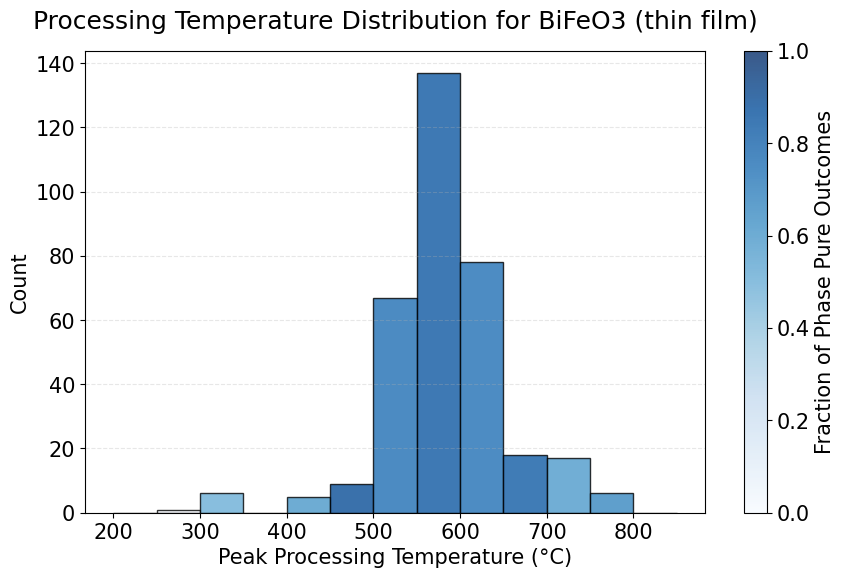

In [6]:
# FIGURE 3b — peak processing temperature vs. phase purity

# =============================================================================
# Phase purity vs. peak processing temperature
#
# Units are mined verbatim from the text and are NOT pre-normalized: temperatures
# appear as °C, K and °F plus OCR variants ('c', 'oc', '°', '℃', 'ºC') and blanks.
# Reading `max_value` directly therefore mixes scales — an anneal recorded as
# "1073 K" is 800 °C but reads as 1073 on a °C axis. to_celsius() below resolves
# the unit (falling back to the `raw_string` when `unit` is blank or junk) and
# returns one scale, or None when the unit is genuinely ambiguous, so such
# records are excluded rather than silently misplaced.
#
# Each record's peak temperature is the maximum resolved operation temperature,
# in °C. Bar colour encodes the fraction of phase-pure outcomes in that 50 °C
# bin (darker blue = higher purity).
# =============================================================================

import re
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 15})

# --- Unit normalization ------------------------------------------------------
_C_UNITS = {"°c", "c", "oc", "0c", "℃", "ºc", "º", "°", "o", "degc", "deg c",
            "degree", "degrees", "celsius", "centigrade"}
_K_UNITS = {"k", "°k", "kelvin"}
_F_UNITS = {"°f", "f", "fahrenheit"}


def _float_or_none(value):
    if value in (None, ""):
        return None
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def to_celsius(temp, field="max_value"):
    """Temperature dict -> °C, or None if the value or its scale is unresolvable."""
    v = _float_or_none((temp or {}).get(field))
    if v is None:
        return None

    u = (temp.get("unit") or "").strip().lower()
    raw = temp.get("raw_string") or ""
    if u in _K_UNITS or (u not in _C_UNITS and u not in _F_UNITS
                         and re.search(r"(?<![a-z])[kK](?![a-z])|kelvin", raw)):
        return v - 273.15
    if u in _F_UNITS or (u not in _C_UNITS
                         and re.search(r"°\s*F|(?<![a-z])F(?![a-z])|fahrenheit", raw, re.I)):
        return (v - 32.0) * 5.0 / 9.0
    if u in _C_UNITS or re.search(r"[℃]|[°ºo0]\s*[cCсС]|(?<![a-z])[cC](?![a-z])|celsi", raw):
        return v
    return None


def peak_temperature_c(entry):
    """Hottest resolvable operation temperature in a record, in °C (None if none)."""
    vals = [to_celsius(op.get("temperature")) for op in entry.get("operations", [])]
    vals = [v for v in vals if v is not None]
    return max(vals) if vals else None


# --- Build parallel arrays: peak temperature (°C) and outcome (1=Pure, 0=Impure).
temps, outcomes = [], []
for entry in bfo:
    peak = peak_temperature_c(entry)
    cls = entry.get("phase_purity", {}).get("classification")
    if peak is not None and cls in ("Pure", "Impure"):
        temps.append(peak)
        outcomes.append(1 if cls == "Pure" else 0)

temps_arr    = np.array(temps)
outcomes_arr = np.array(outcomes)

# Bin into 50 °C windows and compute per-bin purity fraction
bin_edges = np.arange(200, 900, 50)
hist, _    = np.histogram(temps_arr, bins=bin_edges)
bin_purity = []
for i in range(len(bin_edges) - 1):
    mask = (temps_arr >= bin_edges[i]) & (temps_arr < bin_edges[i + 1])
    bin_purity.append(np.mean(outcomes_arr[mask]) if mask.any() else 0)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.Blues
norm = plt.Normalize(0, 1)
bin_width = bin_edges[1] - bin_edges[0]

for i in range(len(hist)):
    ax.bar(
        bin_edges[i], hist[i], width=bin_width, align="edge",
        color=cmap(norm(bin_purity[i])), edgecolor="black", alpha=0.8,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, alpha=0.8, ax=ax, label="Fraction of Phase Pure Outcomes")
ax.set_xlabel("Peak Processing Temperature (°C)")
ax.set_ylabel("Count")
ax.set_title(f"Processing Temperature Distribution for {TARGET_FORMULA} ({TARGET_FORM})", pad=16)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

### Figure 3c | Breakdown of most common impurity phases

Most common BiFeO3 thin-film impurity phases:
    30   Bi2Fe4O9
    20   Bi2O3
    13   Fe2O3
    10   unspecified
     4   SiO2
     3   Bi25FeO40
     2   Bi36Fe42O57
     2   Bi2Fe4O7


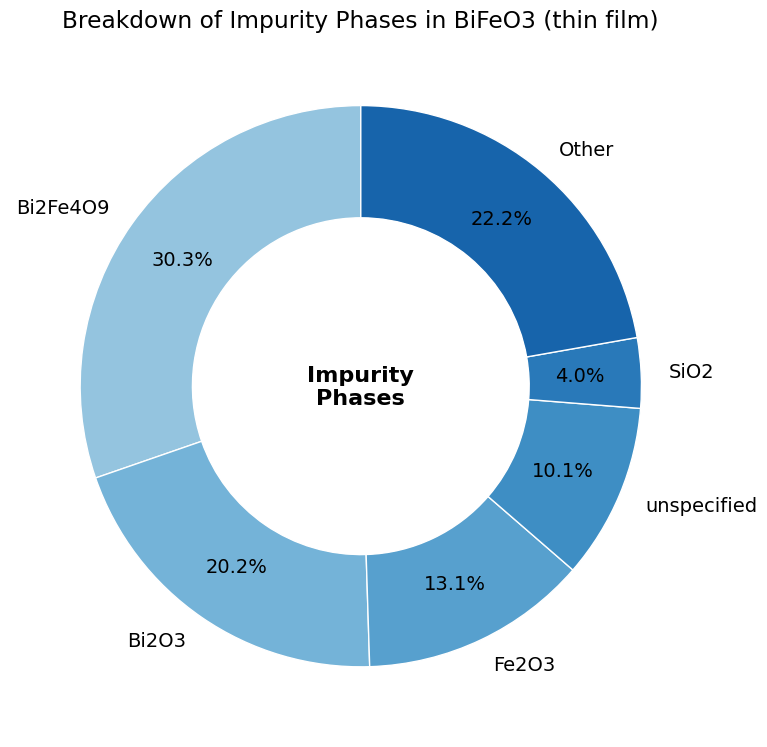

In [7]:
# FIGURE 3c — most common impurity phases

# =============================================================================
# Most common impurity phases in BiFeO3 thin films
#
# Counts each impurity phase recorded across all Impure BFO thin-film records.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams.update({"font.size": 14})

impurity_counts = Counter()
for entry in bfo:
    if entry.get("phase_purity", {}).get("classification") != "Impure":
        continue
    for imp in entry.get("phase_purity", {}).get("impurity_phase", []):
        name = imp.get("material_formula") or imp.get("material_string") if isinstance(imp, dict) else imp
        if name:
            impurity_counts[name] += 1

print("Most common BiFeO3 thin-film impurity phases:")
for phase, cnt in impurity_counts.most_common(8):
    print(f"  {cnt:>4}   {phase}")

# --- Donut chart ---
TOP_N = 5
ordered    = impurity_counts.most_common()
top_labels = [k for k, _ in ordered[:TOP_N]]
top_sizes  = [v for _, v in ordered[:TOP_N]]
other_size = sum(v for _, v in ordered[TOP_N:])
if other_size:
    top_labels.append("Other")
    top_sizes.append(other_size)

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(top_labels)))

ax.pie(
    top_sizes, labels=top_labels, startangle=90,
    colors=colors, wedgeprops={"width": 0.4, "edgecolor": "w"},
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    pctdistance=0.78,
)
fig.gca().add_artist(plt.Circle((0, 0), 0.60, fc="white"))
ax.text(0, 0, "Impurity\nPhases", ha="center", va="center", fontsize=16, weight="bold")
ax.set_title(f"Breakdown of Impurity Phases in {TARGET_FORMULA} ({TARGET_FORM})")
plt.tight_layout()
plt.show()

<a id="technical-validation"></a>
# Technical Validation

The cells below read the human and LLM annotations in `validation/`:

| File | Contents |
|---|---|
| `classification_human.jsonl` / `classification_LLM.jsonl` | Paper-level synthesis-method and material-type labels for the 200-paper validation set |
| `validation_human.jsonl` / `validation_LLM.jsonl` | The 286 post-processed extraction records (line-aligned: row *i* of one file is the counterpart of row *i* of the other) |
| `paper_level_categories.jsonl` | Per-paper outcome category for the 104 extracted papers |

Run these cells **in order**: the extraction cells reuse the helper functions and the
`entities_to_evaluate` configuration defined by the cell for Table 5.

<a id="table-3"></a>
## Table 3 | Evaluation metrics for classification of papers by synthesis method

> *Rows: MatBERT only, and MatBERT + Gemini 3.0 Flash, for the "Sol Gel" class (support 130).*

The MatBERT-only row is the baseline this pipeline starts from: every one of the 200 sampled
papers reached the LLM because MatBERT had already labeled it sol-gel (at least one paragraph
above the 0.85 score cutoff), so MatBERT-only predicts "sol gel" for all 200 by construction —
recall 1.00 and precision = 130/200.

In [8]:
# =============================================================================
# TABLE 3 — paper-level synthesis method classification
# =============================================================================

import json

def load_jsonl(filename):
    data = {}
    with open(filename, 'r') as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                data[obj['doi']] = obj
    return data

def get_metrics(y_true, y_pred, label):
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == label and p == label)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t != label and p == label)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == label and p != label)
    support = sum(1 for t in y_true if t == label)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1, support

# 1. Load Data
gt = load_jsonl(VALIDATION_DIR / 'classification_human.jsonl')
pred = load_jsonl(VALIDATION_DIR / 'classification_LLM.jsonl')
common_dois = [d for d in gt if d in pred]

# --- CATEGORY 1: Sol-Gel vs Non-Sol-Gel ---
y_true_c1 = ["sol gel" if gt[d]['classification'] == "sol gel synthesis" else "non sol gel" for d in common_dois]
y_pred_c1 = ["sol gel" if pred[d]['classification'] == "sol gel synthesis" else "non sol gel" for d in common_dois]

# MatBERT-only baseline: every sampled paper was already labeled sol-gel upstream.
y_pred_matbert = ["sol gel"] * len(common_dois)

print(f"### Table 3: Synthesis Classification  ({len(common_dois)} papers)")
print(f"{'Method':<24} | {'Classification':<14} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'Support'}")
print("-" * 84)
for method, y_pred in [("MatBERT Only", y_pred_matbert),
                       ("MatBERT and Gemini 3.0", y_pred_c1)]:
    p, r, f1, s = get_metrics(y_true_c1, y_pred, "sol gel")
    print(f"{method:<24} | {'Sol Gel':<14} | {p:.3f} | {r:.3f} | {f1:.3f} | {s}")

### Table 3: Synthesis Classification  (200 papers)
Method                   | Classification | Prec   | Rec    | F1     | Support
------------------------------------------------------------------------------------
MatBERT Only             | Sol Gel        | 0.650 | 1.000 | 0.788 | 130
MatBERT and Gemini 3.0   | Sol Gel        | 0.977 | 0.985 | 0.981 | 130


<a id="table-4"></a>
## Table 4 | Evaluation metrics for classification of sol-gel papers into inorganic or mixed organic-inorganic

> *Based on the composition of the final target material.*

Strict logic: a paper the ground truth does not call sol-gel cannot be 'inorganic' or 'mixed',
so it is scored against a third `noise` label rather than being dropped.

In [9]:
# =============================================================================
# TABLE 4 — material type of sol-gel papers (inorganic vs mixed)
# Reuses gt / pred / common_dois / get_metrics from the Table 3 cell.
# =============================================================================

def get_c2_label(item):
    if item.get('classification') == 'sol gel synthesis':
        if item.get('type') == 'inorganic': return "sol gel inorganic"
        if item.get('type') == 'mixed': return "sol gel mixed"
    return "noise"

y_true_c2 = [get_c2_label(gt[d]) for d in common_dois]
y_pred_c2 = [get_c2_label(pred[d]) for d in common_dois]

print(f"### Table 4: Material Type (Strict)")
print(f"{'Label':<20} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'Support'}")
print("-" * 60)
for label in ["sol gel inorganic", "sol gel mixed"]:
    p, r, f1, s = get_metrics(y_true_c2, y_pred_c2, label)
    print(f"{label:<20} | {p:.3f} | {r:.3f} | {f1:.3f} | {s}")

### Table 4: Material Type (Strict)
Label                | Prec   | Rec    | F1     | Support
------------------------------------------------------------
sol gel inorganic    | 0.981 | 0.911 | 0.944 | 112
sol gel mixed        | 0.667 | 1.000 | 0.800 | 18


<a id="figure-s1"></a>
## Figure S1 | Confusion matrix for the LLM-based paper-level synthesis method classification

> *After the initial MatBERT paragraph classification screening.*

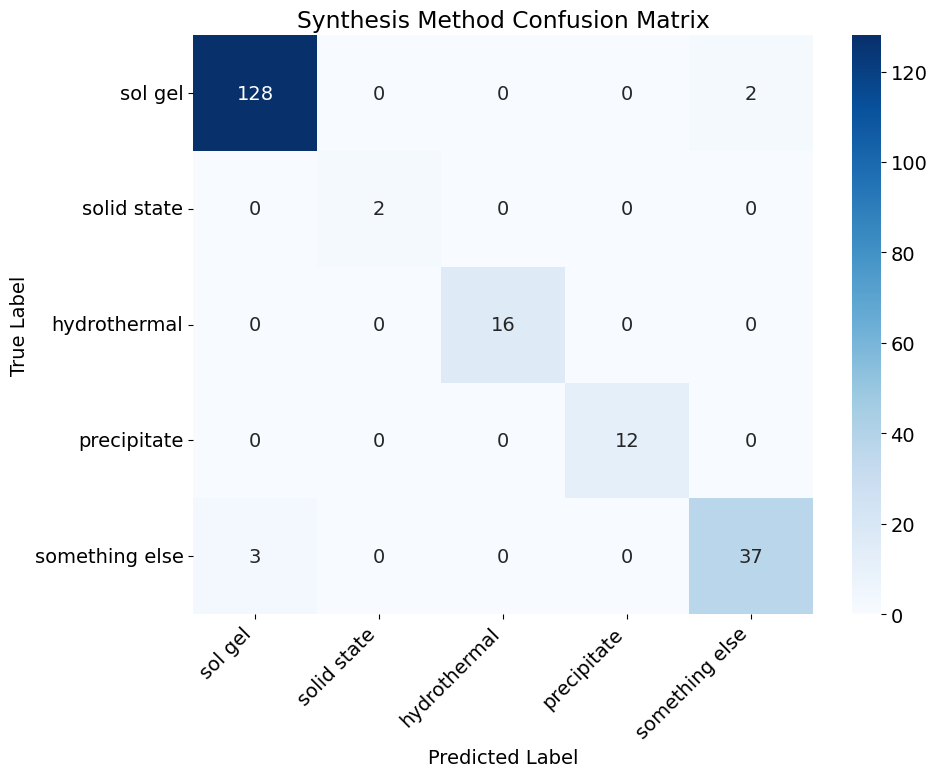

In [10]:
# FIGURE S1 — synthesis method confusion matrix

import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

plt.rcParams.update({'font.size': 14})

def load_jsonl(filename):
    data = {}
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                data[obj['doi']] = obj
    return data

def map_label(label_str):
    """Maps raw JSON labels to your 5 target categories."""
    if not label_str:
        return "something else"
    
    label = label_str.lower()
    if "sol gel" in label:
        return "sol gel"
    elif "solid state" in label:
        return "solid state"
    elif "hydrothermal" in label:
        return "hydrothermal"
    elif "precipitate" in label or "precipitation" in label:
        return "precipitate"
    else:
        return "something else"

# 1. Load Data
gt = load_jsonl(VALIDATION_DIR / 'classification_human.jsonl')
pred = load_jsonl(VALIDATION_DIR / 'classification_LLM.jsonl')
common_dois = [d for d in gt if d in pred]

# 2. Extract and Map Labels
y_true = [map_label(gt[d].get('classification')) for d in common_dois]
y_pred = [map_label(pred[d].get('classification')) for d in common_dois]

# 3. Define Category Order for the Matrix
categories = ["sol gel", "solid state", "hydrothermal", "precipitate", "something else"]

# 4. Generate Plot
cm = confusion_matrix(y_true, y_pred, labels=categories)
df_cm = pd.DataFrame(cm, index=categories, columns=categories)

plt.figure(figsize=(10, 8))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Synthesis Method Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<a id="table-5"></a>
## Table 5 | Evaluation metrics for synthesis data extraction by Gemini 3.0 Flash

> *Normalized fields are used to evaluate (e.g. `material_formula`, `pubchem_CID`).*

Micro-averaged precision, recall and F1 over the 286 line-aligned validation records. Rows map
onto the manuscript table as: `target_formula` → Target Formula, `target_form` → Target Form,
`metal_precursors` → Precursors Formula, `reagents_pubchem` → Reagents PubChem CID,
`op_temp`/`op_time`/`op_ratios`/`op_pH`/`atmosphere` → Operations, `phase_classification` →
Phase Purity Classification, `impurity_formula` → Impurity Phase.

This cell also defines `entities_to_evaluate` and the `compare_*` helpers that every later
validation cell reuses, so that "correct" means exactly the same thing at field, record and
paper level.

In [11]:
# TABLE 5 — field-level extraction metrics

import json
import pandas as pd
from collections import defaultdict

def load_jsonl(filepath, limit=286):
    """Loads JSONL data, handling empty lines and decoding errors."""
    data = []
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            for i, line in enumerate(f):
                if i >= limit: break
                stripped_line = line.strip()
                if not stripped_line:
                    data.append({})
                    continue
                try:
                    data.append(json.loads(stripped_line))
                except json.JSONDecodeError:
                    data.append(None)
    except FileNotFoundError:
        print(f"File {filepath} not found.")
        return None
    return data

def calculate_metrics(tp, fp, fn):
    """Standard Precision/Recall/F1 calculation."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return {
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1': round(f1, 3),
        'Support': tp + fn,
        'TP': tp, 'FP': fp, 'FN': fn
    }

def _is_empty(v):
    """Treats None AND "" (and whitespace) as absent. Required because the
    schema now represents missing values as "" rather than null."""
    return v is None or (isinstance(v, str) and v.strip() == "")

def compare_lists(gt_list, llm_list):
    """Compares lists as sets, ignoring nulls and empty strings."""
    gt_set = set(str(item).strip() for item in (gt_list or []) if item and item is not None)
    llm_set = set(str(item).strip() for item in (llm_list or []) if item and item is not None)
    if not gt_set and not llm_set: return 0, 0, 0
    tp = len(gt_set.intersection(llm_set))
    fp = len(llm_set - gt_set)
    fn = len(gt_set - llm_set)
    return tp, fp, fn

def compare_strings(gt_str, llm_str):
    """Exact string comparison."""
    gt_str = str(gt_str or "").strip()
    llm_str = str(llm_str or "").strip()
    if not gt_str and not llm_str: return 0, 0, 0
    if gt_str == llm_str: return 1, 0, 0
    return 0, (1 if llm_str else 0), (1 if gt_str else 0)

def compare_range_single(gt_dict, llm_dict, min_key='min_value', max_key='max_value'):
    """Treats a numeric range as ONE entity: BOTH min and max must match
    exactly to score a single TP. A partial/incorrect range is one FP and/or FN.
    Empty ('' or None) min AND max => the range is absent."""
    def vals(d):
        if not isinstance(d, dict): return (None, None)
        return d.get(min_key), d.get(max_key)
    g_min, g_max = vals(gt_dict)
    l_min, l_max = vals(llm_dict)
    gt_present = not (_is_empty(g_min) and _is_empty(g_max))
    llm_present = not (_is_empty(l_min) and _is_empty(l_max))
    if not gt_present and not llm_present: return 0, 0, 0
    if gt_present and llm_present and g_min == l_min and g_max == l_max:
        return 1, 0, 0
    return 0, (1 if llm_present else 0), (1 if gt_present else 0)

def extract_field(op, key, sub_key=None):
    """Pulls op[key], optionally drilling into a nested sub_key (e.g. the
    atmosphere dict {raw_string, atmosphere_normalized}). Falls back to the raw
    value if it isn't a dict, so old flat-string layouts still work."""
    val = op.get(key)
    if sub_key and isinstance(val, dict):
        return val.get(sub_key)
    return val

def safe_get_value(data_dict, path):
    """Traverses nested dictionary paths."""
    val = data_dict
    if not isinstance(val, dict): return None
    for key in path:
        if isinstance(val, dict): val = val.get(key)
        else: return None
    return val

# --- Configuration (new normalized schema; atmosphere is now a dict) ---
entities_to_evaluate = {
    'target_formula':       {'type': 'simple',       'path': ['protocol', 'target', 'material_formula']},
    'target_form':          {'type': 'simple',       'path': ['protocol', 'target', 'material_form']},
    'metal_precursors':     {'type': 'sub_key_list', 'path': ['protocol', 'metal_precursors'], 'key': 'material_formula'},
    'reagents_pubchem':     {'type': 'sub_key_list', 'path': ['protocol', 'reagents'], 'key': 'pubchem_CID'},
    # 'characterization':     {'type': 'list',         'path': ['phase_purity', 'characterization_methods', 'characterization_normalized']},
    'impurity_formula':     {'type': 'sub_key_list', 'path': ['phase_purity', 'impurity_phase'], 'key': 'material_formula'},
    'phase_classification': {'type': 'simple',       'path': ['phase_purity', 'classification']},
    'atmosphere':           {'type': 'op_list',      'path': ['operations'], 'key': 'atmosphere', 'sub_key': 'atmosphere_normalized', 'mode': 'exact'},
    'op_time':              {'type': 'op_list',      'path': ['operations'], 'key': 'time',        'mode': 'range', 'min_key': 'min_value', 'max_key': 'max_value'},
    'op_temp':              {'type': 'op_list',      'path': ['operations'], 'key': 'temperature', 'mode': 'range', 'min_key': 'min_value', 'max_key': 'max_value'},
    'op_pH':                {'type':'op_list',       'path': ['operations'], 'key': 'pH',          'mode': 'range', 'min_key': 'min_value', 'max_key': 'max_value'},
    'op_ratios':            {'type': 'op_list',      'path': ['operations'], 'key': 'ratios',      'mode': 'ratio_list'},
}

# --- Execution ---
GT_FILE = VALIDATION_DIR / 'validation_human.jsonl'
LLM_FILE = VALIDATION_DIR / 'validation_LLM.jsonl'
NUM_LINES = 286

gt_data = load_jsonl(GT_FILE, NUM_LINES)
llm_data = load_jsonl(LLM_FILE, NUM_LINES)
results = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

if gt_data and llm_data:
    for i, (gt, llm) in enumerate(zip(gt_data, llm_data)):
        if llm is None: continue

        is_gt_empty = not gt or not any(gt.values())
        is_llm_empty = not llm or not any(llm.values())

        # --- Hallucination Penalty Logic (Field Specific) ---
        if is_gt_empty and not is_llm_empty:
            for entity, config in entities_to_evaluate.items():
                l_val = safe_get_value(llm, config['path'])
                if not l_val: continue
                count = 0
                if config['type'] == 'simple':
                    count = 1
                elif config['type'] in ['list', 'sub_key_list']:
                    count = len([x for x in (l_val or []) if x])
                elif config['type'] == 'op_list':
                    for op in (l_val or []):
                        if config.get('mode') == 'range':
                            field_data = op.get(config['key'])
                            if not isinstance(field_data, dict): continue
                            mn = field_data.get(config.get('min_key', 'min_value'))
                            mx = field_data.get(config.get('max_key', 'max_value'))
                            if not (_is_empty(mn) and _is_empty(mx)): count += 1   # range = 1 entity
                        elif config.get('mode') == 'ratio_list':
                            count += len(op.get(config['key']) or [])
                        else:  # exact (incl. atmosphere via sub_key)
                            if extract_field(op, config['key'], config.get('sub_key')): count += 1
                results[entity]['fp'] += count
                results[entity]['fn'] += count
            continue

        if gt is None: continue

        # --- Standard Comparison ---
        for entity, config in entities_to_evaluate.items():
            g_val = safe_get_value(gt, config['path'])
            l_val = safe_get_value(llm, config['path'])
            tp, fp, fn = 0, 0, 0

            if config['type'] == 'simple':
                tp, fp, fn = compare_strings(g_val, l_val)
            elif config['type'] == 'list':
                tp, fp, fn = compare_lists(g_val, l_val)
            elif config['type'] == 'sub_key_list':
                g_list_raw = [item.get(config['key']) for item in (g_val or [])]
                l_list_raw = [item.get(config['key']) for item in (l_val or [])]
                g_set = set(str(x).strip() for x in g_list_raw if x)
                l_set = set(str(x).strip() for x in l_list_raw if x)
                tp = len(g_set.intersection(l_set))

                gt_count, llm_count = len(g_val or []), len(l_val or [])
                if llm_count > gt_count:
                    fp = max(len(l_set - g_set), llm_count - gt_count)
                else:
                    fp = len(l_set - g_set)

                if gt_count > llm_count:
                    fn = gt_count - llm_count
                else:
                    fn = len(g_set - l_set)

            elif config['type'] == 'op_list':
                ops_gt, ops_llm = (g_val or []), (l_val or [])
                mk, xk = config.get('min_key', 'min_value'), config.get('max_key', 'max_value')
                sk = config.get('sub_key')
                for idx in range(max(len(ops_gt), len(ops_llm))):
                    op_g = ops_gt[idx] if idx < len(ops_gt) else {}
                    op_l = ops_llm[idx] if idx < len(ops_llm) else {}
                    if config['mode'] == 'range':
                        t, f, n = compare_range_single(op_g.get(config['key']), op_l.get(config['key']), mk, xk)
                    elif config['mode'] == 'ratio_list':
                        o_g, o_l = op_g.get(config['key']), op_l.get(config['key'])
                        gr = [f"{r.get('type')}|{r.get('value')}|{r.get('description')}" for r in (o_g or []) if isinstance(r, dict)]
                        lr = [f"{r.get('type')}|{r.get('value')}|{r.get('description')}" for r in (o_l or []) if isinstance(r, dict)]
                        t, f, n = compare_lists(gr, lr)
                    else:  # exact (atmosphere reads the nested atmosphere_normalized)
                        t, f, n = compare_strings(extract_field(op_g, config['key'], sk),
                                                  extract_field(op_l, config['key'], sk))
                    tp += t; fp += f; fn += n

            results[entity]['tp'] += tp
            results[entity]['fp'] += fp
            results[entity]['fn'] += fn

# --- Presentation ---
metrics_list = {k: calculate_metrics(v['tp'], v['fp'], v['fn']) for k, v in results.items()}
print("\nValidation Results:")
print(pd.DataFrame.from_dict(metrics_list, orient='index')[['Precision', 'Recall', 'F1', 'Support', 'TP', 'FP', 'FN']])


Validation Results:
                      Precision  Recall     F1  Support   TP  FP  FN
target_formula            0.965   0.953  0.959      257  245   9  12
target_form               0.948   0.948  0.948      286  271  15  15
metal_precursors          0.950   0.936  0.943      624  584  31  40
reagents_pubchem          0.927   0.956  0.941      732  700  55  32
impurity_formula          0.977   0.896  0.935       48   43   1   5
phase_classification      0.899   0.899  0.899      286  257  29  29
atmosphere                0.950   0.947  0.948      243  230  12  13
op_time                   0.969   0.969  0.969      752  729  23  23
op_temp                   0.969   0.968  0.968      774  749  24  25
op_pH                     0.980   0.980  0.980       50   49   1   1
op_ratios                 0.955   0.969  0.962      262  254  12   8


<a id="table-s2"></a>
## Table S2 | Normalization failures and normalization rates for the affected fields

> *In our validation set, with the corresponding field-level F1 from Table 5.*

A value is counted as a normalization failure when the record carries the pre-normalization
string (`material_string` / `reagent_string` / `raw_string`) but the normalized field it should
have produced is empty. The normalization rate is then `1 − failures / ground-truth entities`,
and the F1 column repeats the field-level F1 from Table 5. Fields with no normalization loss
(`target_form`, `phase_classification`, `op_pH`, `op_ratios`) are omitted, matching Table S2.

In [12]:
# TABLE S2 — normalization failures / normalization rates

# =====================================================================
# TABLE S2 -- normalization failures and normalization rates
#
# D = values the LLM extracted that normalization could not resolve, i.e.
# the pre-normalization string is present but the normalized value is empty.
# Counts come from the normalized GT file, which retains the raw string
# alongside each normalized value (material_string / reagent_string /
# raw_string), so no pre-normalization file is required.
#
# Run AFTER the Table 5 cell: reuses `results` and `load_jsonl`.
# =====================================================================
import pandas as pd

GT_FILE   = VALIDATION_DIR / 'validation_human.jsonl'
NUM_LINES = 286

# field -> (kind, path/op-key, pre-normalization string key, normalized value key)
# Fields absent here did not have normalization failures, so D = 0 by construction.
DROP_SPEC = {
    'target_formula':   ('obj',  ['protocol', 'target'],             'material_string', 'material_formula'),
    'metal_precursors': ('list', ['protocol', 'metal_precursors'],   'material_string', 'material_formula'),
    'reagents_pubchem': ('list', ['protocol', 'reagents'],           'reagent_string',  'pubchem_CID'),
    'impurity_formula': ('list', ['phase_purity', 'impurity_phase'], 'material_string', 'material_formula'),
    'atmosphere':       ('op',   'atmosphere',  'raw_string', 'atmosphere_normalized'),
    'op_time':          ('op',   'time',        'raw_string', 'range'),
    'op_temp':          ('op',   'temperature', 'raw_string', 'range'),
    'op_pH':            ('op',   'pH',          'raw_string', 'range'),
}


def _empty(v):
    return v is None or (isinstance(v, str) and v.strip() == "")


def _dig(d, path):
    for k in path:
        d = d.get(k) if isinstance(d, dict) else None
    return d


def _lost(obj, raw_key, norm_key):
    """One entity is lost if it carries a pre-normalization string but no
    normalized value."""
    if not isinstance(obj, dict) or _empty(obj.get(raw_key)):
        return 0
    if norm_key == 'range':
        return int(_empty(obj.get('min_value')) and _empty(obj.get('max_value')))
    return int(_empty(obj.get(norm_key)))


def count_dropped(records):
    d = {k: 0 for k in DROP_SPEC}
    for rec in records:
        if not rec:
            continue
        for field, (kind, ref, raw_key, norm_key) in DROP_SPEC.items():
            if kind == 'obj':
                d[field] += _lost(_dig(rec, ref), raw_key, norm_key)
            elif kind == 'list':
                for item in (_dig(rec, ref) or []):
                    d[field] += _lost(item, raw_key, norm_key)
            elif kind == 'op':
                for op in (rec.get('operations') or []):
                    d[field] += _lost(op.get(ref), raw_key, norm_key)
    return d



# Manuscript row labels for the evaluated fields.
FIELD_LABELS = {
    'target_formula':   'Target',
    'metal_precursors': 'Precursor',
    'reagents_pubchem': 'Reagents',
    'impurity_formula': 'Impurity Phase',
    'atmosphere':       'Atmosphere',
    'op_time':          'Time',
    'op_temp':          'Temperature',
}


def _f1(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    return 2 * p * r / (p + r) if (p + r) else 0.0


dropped = count_dropped(load_jsonl(GT_FILE, NUM_LINES))

rows = []
for field, label in FIELD_LABELS.items():
    D = dropped.get(field, 0)
    if D == 0:                      # no normalization loss -> not in Table S2
        continue
    tp, fp, fn = results[field]['tp'], results[field]['fp'], results[field]['fn']
    gt_entities = tp + fn + D       # ground-truth entities before exclusions
    rows.append({
        'Field': label,
        'Normalization Failures (count)': D,
        'Normalization Rate': round(1 - D / gt_entities, 3),
        'F1': round(_f1(tp, fp, fn), 3),
    })

table_s2 = pd.DataFrame(rows)
print("Table S2 -- normalization failures and normalization rates")
print(f"Fields with no normalization loss are omitted: "
      f"{', '.join(f for f in results if dropped.get(f, 0) == 0)}\n")
print(table_s2.to_string(index=False))

Table S2 -- normalization failures and normalization rates
Fields with no normalization loss are omitted: target_form, phase_classification, op_pH, op_ratios

         Field  Normalization Failures (count)  Normalization Rate    F1
        Target                              26               0.908 0.959
     Precursor                              47               0.930 0.943
      Reagents                              74               0.908 0.941
Impurity Phase                              17               0.738 0.935
    Atmosphere                               2               0.992 0.948
          Time                              15               0.980 0.969
   Temperature                              56               0.933 0.968


<a id="table-s3"></a>
## Table S3 and Figure S2 | Per-class phase purity classification metrics

> *Table S3: per-class evaluation metrics of phase purity classification performance.
> Figure S2: per-class confusion matrix for phase purity outcomes classification.*

The `classification_report` printed below is Table S3 (Pure 0.91/0.99/0.95 n=202,
Impure 0.96/0.94/0.95 n=50, Insufficient info 1.00/0.37/0.54 n=27); the heatmap is Figure S2.

                   precision    recall  f1-score   support

             Pure       0.91      0.99      0.95       202
           Impure       0.96      0.94      0.95        50
Insufficient info       1.00      0.37      0.54        27

         accuracy                           0.92       279
        macro avg       0.96      0.77      0.81       279
     weighted avg       0.93      0.92      0.91       279



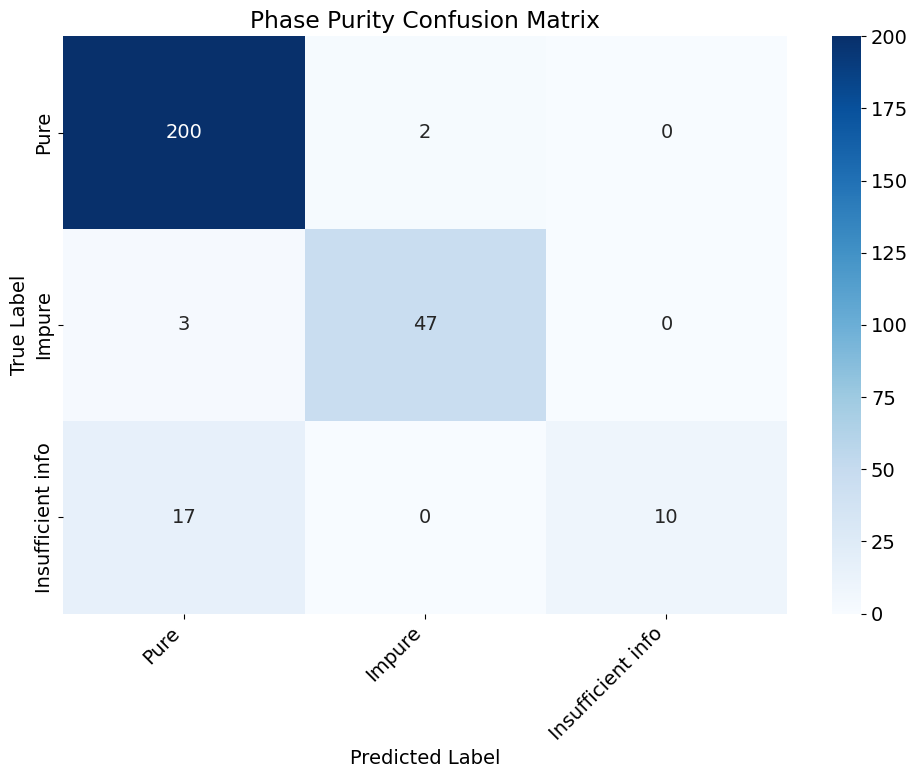

In [13]:
# TABLE S3 + FIGURE S2 — per-class phase purity metrics

import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams.update({'font.size': 14})

def load_jsonl(filename, limit=286):
    """Line-aligned load: the GT and raw files are matched by index, not DOI."""
    data = []
    with open(filename, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= limit: break
            data.append(json.loads(line) if line.strip() else {})
    return data

def get_class(record):
    return ((record or {}).get('phase_purity') or {}).get('classification')

# 1. Load Data
gt = load_jsonl(VALIDATION_DIR / 'validation_human.jsonl')
pred = load_jsonl(VALIDATION_DIR / 'validation_LLM.jsonl')

# 2. Extract Labels (skip records with no ground-truth label)
y_true, y_pred = [], []
for g, p in zip(gt, pred):
    t = get_class(g)
    if t:
        y_true.append(t)
        y_pred.append(get_class(p) or "none")

# 3. Define Category Order for the Matrix
categories = ["Pure", "Impure", "Insufficient info"]

# 4. Generate Plot
cm = confusion_matrix(y_true, y_pred, labels=categories)
df_cm = pd.DataFrame(cm, index=categories, columns=categories)

plt.figure(figsize=(10, 8))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Phase Purity Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 5. Print Report
print(classification_report(y_true, y_pred, labels=categories, target_names=categories))

<a id="record-level"></a>
## Record-level accuracy — Figures S3, S4 and Table S4

The cell below computes the overall record-level accuracy quoted in the manuscript
(**197 / 286 = 0.689**) and the per-field failure counts that Figure S3 plots.

In [14]:
# RECORD-LEVEL ACCURACY (feeds FIGURE S3 and FIGURE S4)

# =====================================================================
# RECORD-LEVEL ACCURACY  (perfect records / total records)
# Denominator = all 286 validation records.
# A record is PERFECT iff it produces zero FP and zero FN across every
# evaluated field, i.e. the whole record is TP-only.
# Run AFTER the extraction-metrics cell: reuses load_jsonl, safe_get_value,
# compare_*, extract_field, _is_empty and entities_to_evaluate so that
# "correct" means exactly what it means in the field-level table.
# =====================================================================
import pandas as pd
from collections import defaultdict

GT_FILE   = VALIDATION_DIR / 'validation_human.jsonl'
LLM_FILE  = VALIDATION_DIR / 'validation_LLM.jsonl'
NUM_LINES = 286

gt_data  = load_jsonl(GT_FILE,  NUM_LINES)
llm_data = load_jsonl(LLM_FILE, NUM_LINES)


def _count_entities(llm, config):
    """Number of entities a field holds in the prediction. Used to penalise
    records whose ground truth is empty (nothing should have been extracted)."""
    l_val = safe_get_value(llm, config['path'])
    if not l_val:
        return 0
    if config['type'] == 'simple':
        return 1
    if config['type'] in ('list', 'sub_key_list'):
        return len([x for x in (l_val or []) if x])
    if config['type'] == 'op_list':
        count = 0
        for op in (l_val or []):
            if config.get('mode') == 'range':
                fd = op.get(config['key'])
                if not isinstance(fd, dict):
                    continue
                mn = fd.get(config.get('min_key', 'min_value'))
                mx = fd.get(config.get('max_key', 'max_value'))
                if not (_is_empty(mn) and _is_empty(mx)):
                    count += 1
            elif config.get('mode') == 'ratio_list':
                count += len(op.get(config['key']) or [])
            else:
                if extract_field(op, config['key'], config.get('sub_key')):
                    count += 1
        return count
    return 0


def score_record(gt, llm):
    """{field: (tp, fp, fn)} for one record, using the same comparison rules
    as the aggregate field-level table."""
    per_field = {}
    is_gt_empty  = (not gt)  or (not any(gt.values()))
    is_llm_empty = (not llm) or (not any(llm.values()))

    # Ground truth holds no recipe but the model emitted one: every entity it
    # invented counts as both an FP and an FN (same rule as the cell above).
    if is_gt_empty and not is_llm_empty:
        for entity, config in entities_to_evaluate.items():
            c = _count_entities(llm, config)
            per_field[entity] = (0, c, c)
        return per_field

    for entity, config in entities_to_evaluate.items():
        g_val = safe_get_value(gt,  config['path'])
        l_val = safe_get_value(llm, config['path'])
        tp = fp = fn = 0

        if config['type'] == 'simple':
            tp, fp, fn = compare_strings(g_val, l_val)

        elif config['type'] == 'list':
            tp, fp, fn = compare_lists(g_val, l_val)

        elif config['type'] == 'sub_key_list':
            g_set = set(str(item.get(config['key'])).strip()
                        for item in (g_val or []) if item.get(config['key']))
            l_set = set(str(item.get(config['key'])).strip()
                        for item in (l_val or []) if item.get(config['key']))
            tp = len(g_set & l_set)
            gt_count, llm_count = len(g_val or []), len(l_val or [])
            fp = max(len(l_set - g_set), llm_count - gt_count) if llm_count > gt_count else len(l_set - g_set)
            fn = (gt_count - llm_count) if gt_count > llm_count else len(g_set - l_set)

        elif config['type'] == 'op_list':
            ops_gt, ops_llm = (g_val or []), (l_val or [])
            mk = config.get('min_key', 'min_value')
            xk = config.get('max_key', 'max_value')
            sk = config.get('sub_key')
            for idx in range(max(len(ops_gt), len(ops_llm))):
                op_g = ops_gt[idx]  if idx < len(ops_gt)  else {}
                op_l = ops_llm[idx] if idx < len(ops_llm) else {}
                if config['mode'] == 'range':
                    t, f, n = compare_range_single(op_g.get(config['key']),
                                                  op_l.get(config['key']), mk, xk)
                elif config['mode'] == 'ratio_list':
                    gr = [f"{r.get('type')}|{r.get('value')}|{r.get('description')}"
                          for r in (op_g.get(config['key']) or []) if isinstance(r, dict)]
                    lr = [f"{r.get('type')}|{r.get('value')}|{r.get('description')}"
                          for r in (op_l.get(config['key']) or []) if isinstance(r, dict)]
                    t, f, n = compare_lists(gr, lr)
                else:
                    t, f, n = compare_strings(extract_field(op_g, config['key'], sk),
                                              extract_field(op_l, config['key'], sk))
                tp += t; fp += f; fn += n

        per_field[entity] = (tp, fp, fn)
    return per_field


# --- score all 286 records ---
rows = []
for i, (gt, llm) in enumerate(zip(gt_data, llm_data)):
    if gt is None or llm is None:          # unparseable line = not a perfect record
        rows.append({'idx': i, 'perfect': False, 'tp': 0, 'fp': 0, 'fn': 0,
                     'bad_fields': ['<unparseable>']})
        continue
    pf = score_record(gt, llm)
    tp = sum(v[0] for v in pf.values())
    fp = sum(v[1] for v in pf.values())
    fn = sum(v[2] for v in pf.values())
    rows.append({'idx': i, 'perfect': (fp == 0 and fn == 0),
                 'tp': tp, 'fp': fp, 'fn': fn,
                 'bad_fields': [k for k, v in pf.items() if v[1] or v[2]]})

rec = pd.DataFrame(rows)

total     = len(rec)
n_perfect = int(rec['perfect'].sum())

print("=" * 66)
print("RECORD-LEVEL ACCURACY  (perfect records / total records)")
print(f"A record is perfect only if it produces zero FP and zero FN across")
print(f"all {len(entities_to_evaluate)} evaluated fields.")
print("=" * 66)
print(f"  total records ........... {total}")
print(f"  perfect records ......... {n_perfect}")
print(f"  imperfect records ....... {total - n_perfect}")
print(f"  record-level accuracy ... {n_perfect / total:.3f}  ({100 * n_perfect / total:.1f}%)")

# --- which fields break the imperfect records ---
fail_counts = defaultdict(int)
for bf in rec.loc[~rec['perfect'], 'bad_fields']:
    for f in bf:
        fail_counts[f] += 1
n_imperfect = total - n_perfect

print(f"\nFields responsible for the {n_imperfect} imperfect records "
      f"(a record can fail on more than one):")
fail_df = (pd.DataFrame({'records_failed': fail_counts})
             .sort_values('records_failed', ascending=False))
fail_df['share_of_imperfect'] = (fail_df['records_failed'] / n_imperfect).round(3)
print(fail_df)

print("\nErrors per record (FP+FN) — shows how many imperfect records are near-misses:")
print((rec['fp'] + rec['fn']).value_counts().sort_index())

RECORD-LEVEL ACCURACY  (perfect records / total records)
A record is perfect only if it produces zero FP and zero FN across
all 11 evaluated fields.
  total records ........... 286
  perfect records ......... 197
  imperfect records ....... 89
  record-level accuracy ... 0.689  (68.9%)

Fields responsible for the 89 imperfect records (a record can fail on more than one):
                      records_failed  share_of_imperfect
metal_precursors                  43               0.483
phase_classification              29               0.326
reagents_pubchem                  26               0.292
op_temp                           17               0.191
target_form                       15               0.169
op_time                           14               0.157
target_formula                    12               0.135
op_ratios                         12               0.135
atmosphere                         9               0.101
impurity_formula                   6               0.067

### Figure S3 | Most common fields responsible for an imperfect record

> *(One or more error in any field.) Note that an imperfect record can contribute to errors in
> multiple fields.*

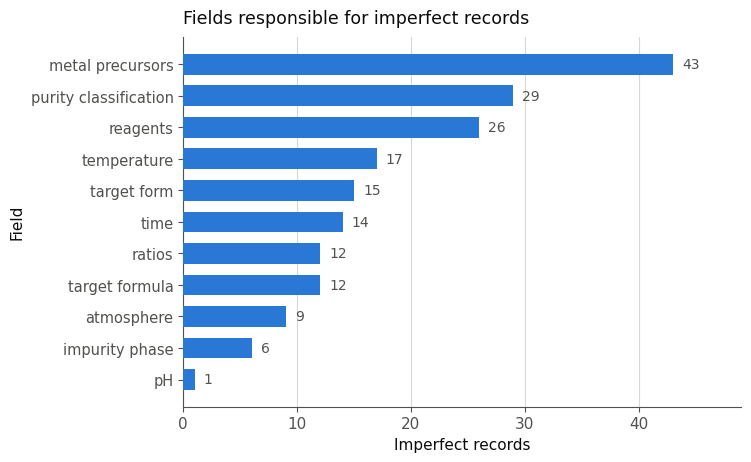

In [15]:
# FIGURE S3 — fields responsible for imperfect records

# --- shared style (run once) ---------------------------------------------
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

BLUE, GRAY = '#2a78d6', '#bdbcb6'
INK, INK2, GRID = '#0b0b0b', '#52514e', '#d8d7d1'

mpl.rcParams.update({
    'font.size': 11, 'axes.edgecolor': INK2, 'axes.labelcolor': INK,
    'text.color': INK, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

PRETTY = {
    'target_formula': 'target formula', 'target_form': 'target form',
    'metal_precursors': 'metal precursors', 'reagents_pubchem': 'reagents',
    'impurity_formula': 'impurity phase', 'phase_classification': 'purity classification',
    'atmosphere': 'atmosphere', 'op_time': 'time', 'op_temp': 'temperature',
    'op_pH': 'pH', 'op_ratios': 'ratios', '<unparseable>': 'unparseable',
}

# --- FIGURE S3: fields responsible for imperfect records ------------------
fig1, ax = plt.subplots(figsize=(7.2, 4.8))
fa = fail_df.sort_values('records_failed')
y = np.arange(len(fa))
ax.barh(y, fa['records_failed'].values, height=0.66, color=BLUE, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels([PRETTY.get(f, f) for f in fa.index], fontsize=10.5)
for yi, v in zip(y, fa['records_failed'].values):
    ax.text(v + 0.8, yi, str(v), va='center', fontsize=10, color=INK2)
ax.set_xlim(0, fa['records_failed'].max() * 1.14)
ax.set_xlabel('Imperfect records')
ax.set_ylabel('Field')
ax.xaxis.grid(True, color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.set_title('Fields responsible for imperfect records', fontsize=12.5,
             loc='left', pad=10)
plt.show()

### Figure S4 | Distribution of errors per record

> *Note that there is a total of 286 records of which 197 are perfect and 89 are imperfect,
> resulting in an overall accuracy of 0.689.*

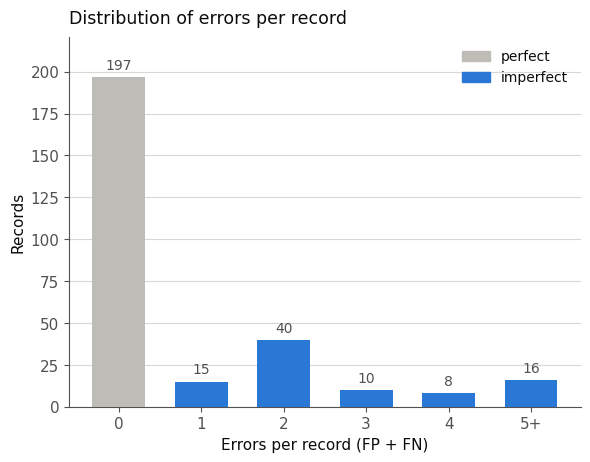

In [16]:
# FIGURE S4 — distribution of errors per record

# --- FIGURE S4: errors per record -----------------------------------------
fig2, ax = plt.subplots(figsize=(6.6, 4.8))
err = rec['fp'] + rec['fn']
bins = ['0', '1', '2', '3', '4', '5+']
counts = [int((err == k).sum()) for k in range(5)] + [int((err >= 5).sum())]
x = np.arange(len(bins))
ax.bar(x, counts, width=0.64, color=[GRAY] + [BLUE] * 5, zorder=3)
for xi, c in zip(x, counts):
    ax.text(xi, c + max(counts) * 0.015, str(c), ha='center', va='bottom',
            fontsize=10, color=INK2)
ax.set_xticks(x)
ax.set_xticklabels(bins, fontsize=11)
ax.set_ylim(0, max(counts) * 1.12)
ax.set_xlabel('Errors per record (FP + FN)')
ax.set_ylabel('Records')
ax.yaxis.grid(True, color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.set_title('Distribution of errors per record', fontsize=12.5, loc='left', pad=10)
ax.legend([plt.Rectangle((0, 0), 1, 1, color=GRAY),
           plt.Rectangle((0, 0), 1, 1, color=BLUE)],
          ['perfect', 'imperfect'], frameon=False, fontsize=10,
          loc='upper right')
plt.show()

<a id="table-s4"></a>
### Table S4 | Record-level accuracy metrics (correct records / total records)

> *An extracted synthesis record is "correct" if it matches a ground truth data record and
> produces no errors (FP or FN) for the described fields.*

In [17]:
# TABLE S4 — record-level accuracy by field category

# =====================================================================
# RECORD-LEVEL ACCURACY BY FIELD CATEGORY
# A record is correct for a category if EVERY field in that category has
# zero FP and zero FN. Denominator = all 286 validation records.
# Run AFTER the record-level cell: reuses score_record, gt_data, llm_data.
# =====================================================================
import numpy as np
import pandas as pd

FIELDS = list(entities_to_evaluate.keys())

# per-record, per-field: clean (no FP, no FN) or not
clean_rows = []
for gt, llm in zip(gt_data, llm_data):
    if gt is None or llm is None:
        clean_rows.append([False] * len(FIELDS))
        continue
    pf = score_record(gt, llm)
    clean_rows.append([(pf[f][1] == 0 and pf[f][2] == 0) for f in FIELDS])
CLEAN = np.array(clean_rows, dtype=bool)
N_REC = CLEAN.shape[0]

# --- building blocks -----------------------------------------------------
TARGET     = ['target_formula']       
PRECURSOR  = ['metal_precursors']
REAGENTS   = ['reagents_pubchem']
OUTCOME    = ['phase_classification', 'impurity_formula']
CONDITIONS = ['op_temp', 'op_time', 'op_pH', 'atmosphere']

CATEGORIES = [
    ('Target',
     'Target only',
     TARGET),
    ('Target-Precursor',
     'Target and precursor',
     TARGET + PRECURSOR),
    ('Target-Outcome',
     'Target and synthesis outcomes (phase classification, and impurity phase)',
     TARGET + OUTCOME),
    ('Synthesis conditions',
     'Temperature, time, pH, and atmosphere',
     CONDITIONS),
    ('Target-Precursor-Reagents-Outcome',
     'Target, precursor, reagents, and synthesis outcomes',
     TARGET + PRECURSOR + REAGENTS + OUTCOME),
    ('Target-Precursor-Conditions-Outcome',
     'Target, precursor, synthesis conditions, and synthesis outcomes',
     TARGET + PRECURSOR + CONDITIONS + OUTCOME),
    ('Overall',
     'All 11 fields',
     FIELDS),
]

rows = []
for category, description, fields in CATEGORIES:
    fields = list(dict.fromkeys(fields))                    # de-dup, keep order
    n_correct = int(CLEAN[:, [FIELDS.index(f) for f in fields]].all(axis=1).sum())
    rows.append({
        'Category': category,
        'Description': description,
        '# of Fields': len(fields),
        'Correct / Total': f'{n_correct} / {N_REC}',
        'Accuracy': round(n_correct / N_REC, 3),
    })

table = pd.DataFrame(rows)
print(table.to_string(index=False))

                           Category                                                              Description  # of Fields Correct / Total  Accuracy
                             Target                                                              Target only            1       274 / 286     0.958
                   Target-Precursor                                                     Target and precursor            2       235 / 286     0.822
                     Target-Outcome Target and synthesis outcomes (phase classification, and impurity phase)            3       249 / 286     0.871
               Synthesis conditions                                    Temperature, time, pH, and atmosphere            4       262 / 286     0.916
  Target-Precursor-Reagents-Outcome                      Target, precursor, reagents, and synthesis outcomes            5       215 / 286     0.752
Target-Precursor-Conditions-Outcome          Target, precursor, synthesis conditions, and synthesis outcomes    

<a id="table-s5"></a>
## Table S5 | Breakdown of the 104 papers contributing to the overall paper-level accuracy of 0.490

> *A paper is considered "correct" only if all experimental variants were recovered from the
> paper, with one record per variant, and each record containing no field-level errors. Using a
> looser definition that allows for merged records would raise paper-level accuracy to 0.635.*

In [18]:
# TABLE S5 — paper-level breakdown

import json
import pandas as pd
from collections import defaultdict

CATEGORY_FILE = VALIDATION_DIR / 'paper_level_categories.jsonl'
CATEGORIES = ['correct', 'field errors', 'merged', 'split', 'misclassified']

papers = pd.DataFrame([json.loads(l) for l in open(CATEGORY_FILE) if l.strip()])


counts = defaultdict(int)
for r in llm_data:
    d = ((r or {}).get('protocol') or {}).get('doi')
    if d:
        counts[d] += 1
papers['n_llm'] = papers['doi'].map(counts).fillna(0).astype(int)

papers['has_merged']     = papers['category'] == 'merged'
papers['split']          = papers['category'] == 'split'
papers['misclassified']  = papers['category'] == 'misclassified'
papers['correct_strict'] = papers['category'] == 'correct'

N = len(papers)
n_strict = int(papers['correct_strict'].sum())

brk = (papers['category'].value_counts()
       .reindex(CATEGORIES).fillna(0).astype(int)
       .rename_axis('category').reset_index(name='papers'))
brk['share'] = (brk['papers'] / N).round(3)

print("=" * 72)
print(f"PAPER-LEVEL BREAKDOWN  ({N} papers)")
print("=" * 72)
print(brk.to_string(index=False))
print(f"\npaper-level accuracy .................... {n_strict}/{N} = {n_strict/N:.3f}")

n_loose = int((papers["category"].isin(["correct", "merged"])).sum())
print(f"looser definition (merged records allowed) ... {n_loose}/{N} = {n_loose/N:.3f}")

PAPER-LEVEL BREAKDOWN  (104 papers)
     category  papers  share
      correct      51  0.490
 field errors      34  0.327
       merged      15  0.144
        split       2  0.019
misclassified       2  0.019

paper-level accuracy .................... 51/104 = 0.490
looser definition (merged records allowed) ... 66/104 = 0.635


<a id="table-s6"></a>
## Table S6 | Field, record, and paper-level accuracy metrics

In [19]:
# TABLE S6 — master table (field / record / paper)

# =====================================================================
# MASTER TABLE -- field / record / paper
#
# Each level ANDs the level below over a wider scope, so accuracy can only
# fall as you descend the table. "Ceiling" is the highest value the level
# could take GIVEN the level below it, i.e. if every error were packed into
# as few units as possible.
#
# Run AFTER the record-level cell and the paper-level cell:
# reuses score_record, gt_data, llm_data, entities_to_evaluate, papers.
# =====================================================================
import numpy as np
import pandas as pd

FIELDS = list(entities_to_evaluate.keys())

# ---- field x record cleanliness matrix ----------------------------------
CLEAN = np.array([[ (pf[f][1] == 0 and pf[f][2] == 0) for f in FIELDS ]
                  for pf in (score_record(a, b) for a, b in zip(gt_data, llm_data))],
                 dtype=bool)
N_REC, N_F = CLEAN.shape
per_field = dict(zip(FIELDS, CLEAN.mean(axis=0)))

n_cells       = CLEAN.size
n_cells_clean = int(CLEAN.sum())
n_rec_perfect = int(CLEAN.all(axis=1).sum())

N_PAP        = len(papers)
n_pap_strict = int(papers['correct_strict'].sum())

# ---- ceilings -----------------------------------------------------------
# record given field: a record needs EVERY field clean, so it cannot beat
# the weakest field's clean rate.
ceil_record = min(per_field.values())

# paper given record + structure: papers that fail structurally are doomed
# regardless of field content, so pack the imperfect records into them first;
# any left over must break further papers, largest ones first.
sizes = papers.set_index('doi')['n_llm'].sort_values(ascending=False)
n_bad_records = N_REC - n_rec_perfect
doomed = papers[papers['has_merged'] | papers['misclassified'] | papers['split']]
n_doomed = len(doomed)
extra = max(0, n_bad_records - int(doomed['n_llm'].sum()))
extra_papers = 0
for s in sizes[~sizes.index.isin(doomed['doi'])]:
    if extra <= 0:
        break
    extra -= s
    extra_papers += 1
ceil_paper = (N_PAP - n_doomed - extra_papers) / N_PAP

# ---- assemble -----------------------------------------------------------
master = pd.DataFrame([
    {'Level': 'Field',
     'Criterion': 'one field of one record exactly right (no FP, no FN)',
     'Unit': 'field-record', 'N': n_cells,
     'Correct': n_cells_clean, 'Accuracy': n_cells_clean / n_cells,
     'Ceiling': 1.000},
    {'Level': 'Record',
     'Criterion': f'all {N_F} fields of the record right',
     'Unit': 'record', 'N': N_REC,
     'Correct': n_rec_perfect, 'Accuracy': n_rec_perfect / N_REC,
     'Ceiling': ceil_record},
    {'Level': 'Paper',
     'Criterion': ('every record right, variant count matches, '
                   'and every record resolves to one experiment'),
     'Unit': 'paper', 'N': N_PAP,
     'Correct': n_pap_strict, 'Accuracy': n_pap_strict / N_PAP,
     'Ceiling': ceil_paper},
])
master['Accuracy']    = master['Accuracy'].round(3)
master['Ceiling']     = master['Ceiling'].round(3)
master['Correct / N'] = master['Correct'].astype(str) + ' / ' + master['N'].astype(str)

pd.set_option('display.width', 200, 'display.max_colwidth', 70)
print("=" * 104)
print("MASTER TABLE -- each level ANDs the level below over a wider scope")
print("=" * 104)
print(master[['Level', 'Criterion', 'Unit', 'Correct / N',
              'Accuracy', 'Ceiling']].to_string(index=False))

MASTER TABLE -- each level ANDs the level below over a wider scope
 Level                                                                              Criterion         Unit Correct / N  Accuracy  Ceiling
 Field                                   one field of one record exactly right (no FP, no FN) field-record 2962 / 3146     0.942    1.000
Record                                                      all 11 fields of the record right       record   197 / 286     0.689    0.850
 Paper every record right, variant count matches, and every record resolves to one experiment        paper    51 / 104     0.490    0.769


<a id="not-generated-by-code"></a>
# Not generated by code

These manuscript items are not figures or tables, or have no computational step to reproduce:

| Item | Where it lives |
|---|---|
| **Figure 1** — data extraction pipeline schematic | `scripts/images/sg-fig1.svg`, `sg-fig1.png` |
| **Table 1** — data records format | Transcribed as markdown [above](#table-1) |
| **Table S1** — worked TP/FP/FN example | Manuscript SI; a modified illustrative record, not a real one |
| **Supplementary Sec. 1** — paper filtration prompt | Manuscript SI; raw filtration outputs in `paper_filtration.jsonl` |
| **Supplementary Sec. 2** — paper extraction prompt | Manuscript SI |
| **Supplementary Sec. 3** — example post-processed record | Manuscript SI; the record is in `sol_gel_dataset.jsonl` under DOI `10.1016/j.jmmm.2009.12.033` |
| **Usage Notes** — semantic consistency counts | `post-processing/semantic_inconsistency.py` |